In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from pathlib import Path
from collections import Counter
import re

pd.set_option("display.max_columns", None)
pd.set_option("display.max_colwidth", 200)

In [2]:
BASE_DIR = Path("..")
PROCESSED_DATA_PATH = BASE_DIR / "data" / "processed" / "creepypastas_clean.csv"

df = pd.read_csv(PROCESSED_DATA_PATH)

df.head()

,title,story_text,text_lower,rating,rating_numeric,story_length_chars,word_count,tags,categories,estimated_reading_time,publish_date
0,"If You’re Armed and at the Glenmont Metro, Please Shoot Me","If you’re armed and at the Glenmont metro, please shoot me.\nMake it a headshot. Shoot me in the temple, aiming slightly downwards. I need the bullet to travel the shortest possible distance throu...","if you’re armed and at the glenmont metro, please shoot me.\nmake it a headshot. shoot me in the temple, aiming slightly downwards. i need the bullet to travel the shortest possible distance throu...",9.25,9.25,19493,3560,"drug trials, drugs, experimentation, experiments, madness, Peter Frost David, psychological, psychological horror, sci-fi, science, science fiction, time","Drugs and Addictions, Madness, Paranoia, and Mental Illness, Psychological Horror, Science and Experimentation, Science Fiction and Aliens",12 minutes,2020-02-20
1,A Shattered Life,"I don’t know when you’re going to read this, but I can tell you when it started: I was out for a walk alone in the woods when the entity came for me. It was beyond a blur. It was, for lack of a be...","i don’t know when you’re going to read this, but i can tell you when it started: i was out for a walk alone in the woods when the entity came for me. it was beyond a blur. it was, for lack of a be...",9.13,9.13,20837,3919,"disease, entities, Matt Dymerski, monsters, paranormal, supernatural, time travel","Madness, Paranoia, and Mental Illness, Monsters, Creatures, and Cryptids, Science Fiction and Aliens",14 minutes,2020-07-22
2,My Father Punished Me When I Talked to Ghosts,"I’ve been blind since birth. As I grew up, everything was described to me in such vivid detail that I didn’t even realize why it was that important to see, especially having no reference point to ...","i’ve been blind since birth. as i grew up, everything was described to me in such vivid detail that i didn’t even realize why it was that important to see, especially having no reference point to ...",9.12,9.12,10859,2135,"abductions, blindness, child abuse, childhood, children, crimes, deaths, deception, investigations, kidnappings, kids, lies, murders","Abductions and Kidnappings, Children and Childhood, Deaths, Murders, and Disappearances, Investigations and Crimes",8 minutes,2019-12-10
3,Distorted Warning Signals,"When I got the first one, I was literally seconds away from stepping onto the plane when a call from “UNKNOWN” blared from my cell phone. It was a ringtone I hadn’t heard before, one I was pretty ...","when i got the first one, i was literally seconds away from stepping onto the plane when a call from “unknown” blared from my cell phone. it was a ringtone i hadn’t heard before, one i was pretty ...",9.12,9.12,4150,768,Ashley Rose Wellman,"Beings and Entities, Deaths, Murders, and Disappearances, Madness, Paranoia, and Mental Illness, Monsters, Creatures, and Cryptids, Occult, Magic, and Witchcraft, Psychological Horror, Survival Ho...",3 minutes,2019-07-13
4,He Who Wanders,"I missed the scorching wind of Andalusia. How it pours sunlight onto your face, toying with eyelashes, flattening dry sand against cheeks and milling around hair. I missed the smell of the valley ...","i missed the scorching wind of andalusia. how it pours sunlight onto your face, toying with eyelashes, flattening dry sand against cheeks and milling around hair. i missed the smell of the valley ...",9.12,9.12,32767,6021,Simon Simonian,Beings and Entities,22 minutes,2017-01-24


In [3]:
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])

df.info()

Rows: 3478
Columns: 11
<class 'pandas.DataFrame'>
RangeIndex: 3478 entries, 0 to 3477
Data columns (total 11 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   title                   3478 non-null   str    
 1   story_text              3478 non-null   str    
 2   text_lower              3478 non-null   str    
 3   rating                  3478 non-null   float64
 4   rating_numeric          3478 non-null   float64
 5   story_length_chars      3478 non-null   int64  
 6   word_count              3478 non-null   int64  
 7   tags                    3478 non-null   str    
 8   categories              3478 non-null   str    
 9   estimated_reading_time  3478 non-null   str    
 10  publish_date            3478 non-null   str    
dtypes: float64(2), int64(2), str(7)
memory usage: 299.0 KB


In [4]:
df[["title", "rating_numeric", "story_length_chars", "word_count"]].head()

,title,rating_numeric,story_length_chars,word_count
0,"If You’re Armed and at the Glenmont Metro, Please Shoot Me",9.25,19493,3560
1,A Shattered Life,9.13,20837,3919
2,My Father Punished Me When I Talked to Ghosts,9.12,10859,2135
3,Distorted Warning Signals,9.12,4150,768
4,He Who Wanders,9.12,32767,6021


In [5]:
df["rating_numeric"].describe()

count    3478.000000
mean        7.566472
std         1.132679
min         0.860000
25%         6.980000
50%         7.790000
75%         8.420000
max         9.250000
Name: rating_numeric, dtype: float64

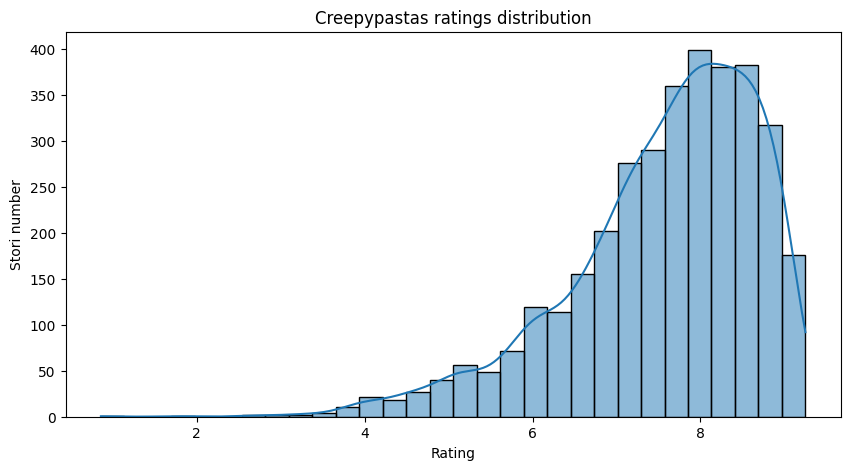

In [6]:
plt.figure(figsize=(10, 5))

sns.histplot(df["rating_numeric"], bins=30, kde=True)

plt.title("Creepypastas ratings distribution")
plt.xlabel("Rating")
plt.ylabel("Stori number")

plt.show()

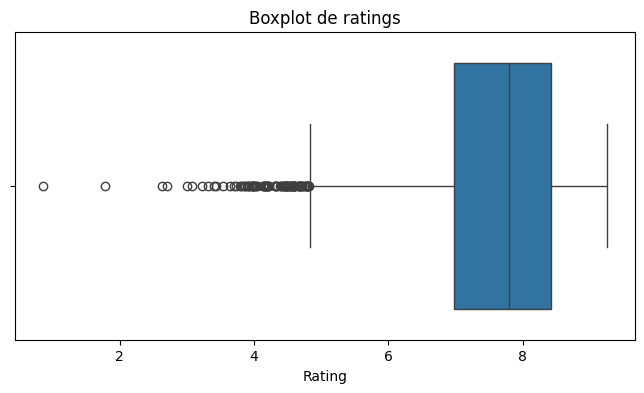

In [7]:
plt.figure(figsize=(8, 4))

sns.boxplot(x=df["rating_numeric"])

plt.title("Boxplot de ratings")
plt.xlabel("Rating")

plt.show()

In [8]:
df["word_count"].describe()

count    3478.000000
mean     2311.520414
std      1740.847215
min        51.000000
25%       933.000000
50%      1873.500000
75%      3273.500000
max      6566.000000
Name: word_count, dtype: float64

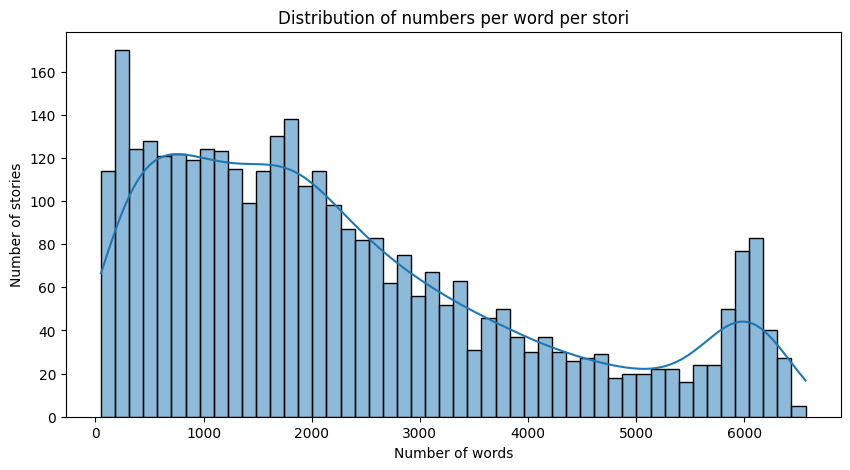

In [9]:
plt.figure(figsize=(10, 5))

sns.histplot(df["word_count"], bins=50, kde=True)

plt.title("Distribution of numbers per word per stori")
plt.xlabel("Number of words")
plt.ylabel("Number of stories")

plt.show()

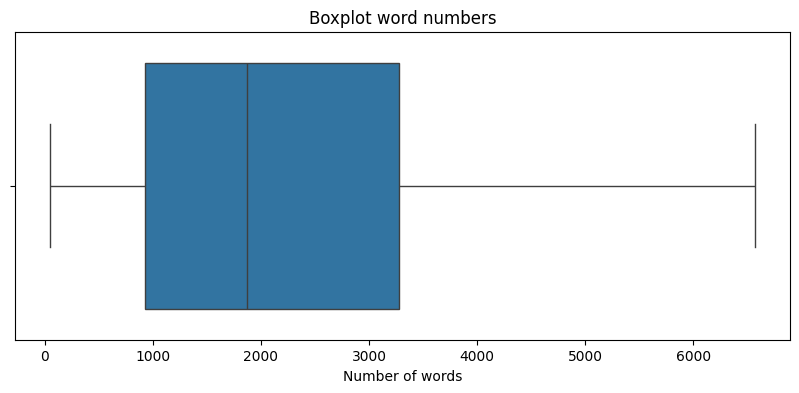

In [10]:
plt.figure(figsize=(10, 4))

sns.boxplot(x=df["word_count"])

plt.title("Boxplot word numbers")
plt.xlabel("Number of words")

plt.show()

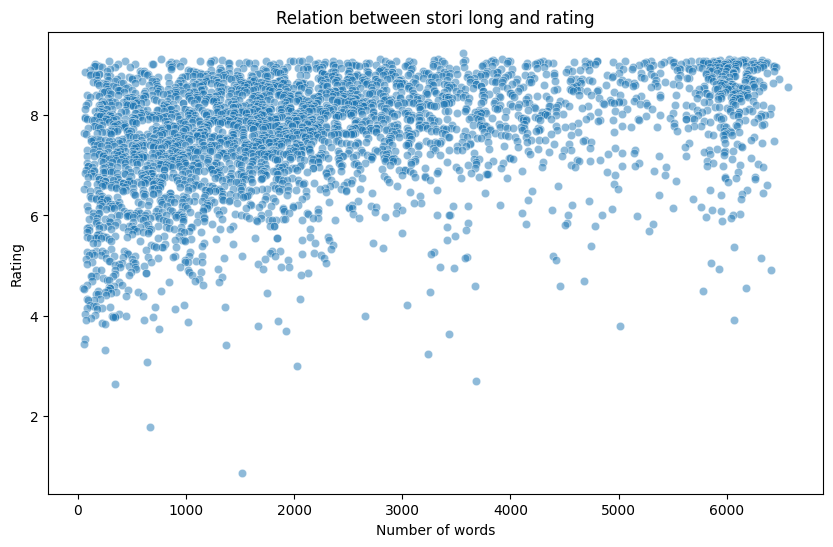

In [11]:
plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=df,
    x="word_count",
    y="rating_numeric",
    alpha=0.5
)

plt.title("Relation between stori long and rating")
plt.xlabel("Number of words")
plt.ylabel("Rating")

plt.show()

In [12]:
correlation = df["word_count"].corr(df["rating_numeric"])

print("Correlation between word_count y rating:", correlation)

Correlation between word_count y rating: 0.34682531261319677


In [25]:
## Interpretation: Story Length and Rating

# The correlation between `word_count` and `rating_numeric` gives an early signal about whether longer stories tend to receive higher ratings.

# A positive correlation suggests that longer stories may be associated with better reception. However, this relationship does not fully explain why a horror story is powerful. Length is only a surface-level variable.

# This supports the next stage of the project: creating deeper narrative features through the Horror Fracture Index.

In [13]:
top_rated = df.sort_values("rating_numeric", ascending=False).head(10)

top_rated[["title", "rating_numeric", "word_count", "estimated_reading_time", "categories"]]

,title,rating_numeric,word_count,estimated_reading_time,categories
0,"If You’re Armed and at the Glenmont Metro, Please Shoot Me",9.25,3560,12 minutes,"Drugs and Addictions, Madness, Paranoia, and Mental Illness, Psychological Horror, Science and Experimentation, Science Fiction and Aliens"
1,A Shattered Life,9.13,3919,14 minutes,"Madness, Paranoia, and Mental Illness, Monsters, Creatures, and Cryptids, Science Fiction and Aliens"
2,My Father Punished Me When I Talked to Ghosts,9.12,2135,8 minutes,"Abductions and Kidnappings, Children and Childhood, Deaths, Murders, and Disappearances, Investigations and Crimes"
3,Distorted Warning Signals,9.12,768,3 minutes,"Beings and Entities, Deaths, Murders, and Disappearances, Madness, Paranoia, and Mental Illness, Monsters, Creatures, and Cryptids, Occult, Magic, and Witchcraft, Psychological Horror, Survival Ho..."
4,He Who Wanders,9.12,6021,22 minutes,Beings and Entities
5,The Living History Project,9.12,2798,10 minutes,"Artifacts and Objects, Deaths, Murders, and Disappearances, Historical Fiction, Journals and Diaries, Locations and Sites, Military and Warfare, Strange and Unexplained, Technology, the Internet, ..."
6,I Found a Letter From My Stalker,9.12,3326,12 minutes,"Body Horror, Madness, Paranoia, and Mental Illness, Strange and Unexplained"
7,Don’t Let Them In,9.11,3838,13 minutes,"Children and Childhood, Drugs and Addictions, Madness, Paranoia, and Mental Illness, Suspense and Thrillers"
8,What Happens When the Stars Go Out,9.11,6142,21 minutes,"Deaths, Murders, and Disappearances, Feelspastas and Happy Endings, Hell and the Afterlife, Strange and Unexplained"
9,The Seer of Possibilities,9.11,5476,19 minutes,Beings and Entities


In [14]:
longest_stories = df.sort_values("word_count", ascending=False).head(10)

longest_stories[["title", "rating_numeric", "word_count", "estimated_reading_time", "categories"]]

,title,rating_numeric,word_count,estimated_reading_time,categories
675,The Pixies,8.57,6566,34 minutes,"Beings and Entities, Folklore and Folktales, Myths and Legends"
454,The Wormhole,8.72,6479,26 minutes,"Beings and Entities, Science Fiction and Aliens, Strange and Unexplained"
187,Strange Things Happen Overnight at Lowe’s,8.96,6459,52 minutes,"Jobs and Occupations, Strange and Unexplained"
171,From Me to You,8.98,6440,41 minutes,"Madness, Paranoia, and Mental Illness"
2092,The Fog Has Eyes,7.49,6438,55 minutes,"Monsters, Creatures, and Cryptids"
256,The Serial Killer Showdown,8.89,6435,39 minutes,"Deaths, Murders, and Disappearances"
555,NoEnd House,8.65,6426,48 minutes,"Beings and Entities, Famous Creepypasta, Locations and Sites, Madness, Paranoia, and Mental Illness, Psychological Horror, Strange and Unexplained, Survival Horror, Suspense and Thrillers"
157,Miss Fortune,8.99,6425,38 minutes,Beings and Entities
3371,The Woods Past Dark,4.90,6407,40 minutes,Strange and Unexplained
1254,Death Dreams,8.14,6405,43 minutes,"Madness, Paranoia, and Mental Illness"


In [15]:
short_high_rated = (
    df[df["word_count"] < df["word_count"].median()]
    .sort_values("rating_numeric", ascending=False)
    .head(10)
)

short_high_rated[["title", "rating_numeric", "word_count", "categories"]]

,title,rating_numeric,word_count,categories
3,Distorted Warning Signals,9.12,768,"Beings and Entities, Deaths, Murders, and Disappearances, Madness, Paranoia, and Mental Illness, Monsters, Creatures, and Cryptids, Occult, Magic, and Witchcraft, Psychological Horror, Survival Ho..."
12,Mommy Sleeps in the Basement,9.10,1255,"Abductions and Kidnappings, Children and Childhood, Deaths, Murders, and Disappearances, Investigations and Crimes"
14,The Well,9.10,1329,"Based on True Events, Beings and Entities, Historical Fiction"
35,Mr. Widemouth,9.09,1740,"Beings and Entities, Children and Childhood, Famous Creepypasta, Madness, Paranoia, and Mental Illness, Monsters, Creatures, and Cryptids, Strange and Unexplained"
37,The Gift Of Mercy,9.09,1232,"Deaths, Murders, and Disappearances, Science Fiction and Aliens, Space and Cosmic Horror"
49,Sadie,9.08,288,"Deaths, Murders, and Disappearances, Famous Creepypasta, Illness and Injuries, Madness, Paranoia, and Mental Illness, Sounds and Voices, Strange and Unexplained, Urban Legends, Video Games and Gaming"
54,Lightning,9.08,437,Strange and Unexplained
55,An Egg,9.08,974,Strange and Unexplained
56,Survival Guide,9.08,1131,"Dark Comedy, Humor, and Parodies, Rites and Rituals"
70,Ickbarr Bigelsteine,9.07,1552,"Artifacts and Objects, Beings and Entities, Children and Childhood, Famous Creepypasta, Feelspastas and Happy Endings, Monsters, Creatures, and Cryptids, Toys and Dolls"


In [26]:
df["categories"] = (
    df["categories"]
    .astype(str)
    .str.replace("\n", " ", regex=False)
    .str.replace("Please wait...", "", regex=False)
    .str.strip()
)

df["tags"] = (
    df["tags"]
    .astype(str)
    .str.replace("\n", " ", regex=False)
    .str.replace("Please wait...", "", regex=False)
    .str.strip()
)

df[["categories", "tags"]].head()

,categories,tags
0,"Drugs and Addictions, Madness, Paranoia, and Mental Illness, Psychological Horror, Science and Experimentation, Science Fiction and Aliens","drug trials, drugs, experimentation, experiments, madness, Peter Frost David, psychological, psychological horror, sci-fi, science, science fiction, time"
1,"Madness, Paranoia, and Mental Illness, Monsters, Creatures, and Cryptids, Science Fiction and Aliens","disease, entities, Matt Dymerski, monsters, paranormal, supernatural, time travel"
2,"Abductions and Kidnappings, Children and Childhood, Deaths, Murders, and Disappearances, Investigations and Crimes","abductions, blindness, child abuse, childhood, children, crimes, deaths, deception, investigations, kidnappings, kids, lies, murders"
3,"Beings and Entities, Deaths, Murders, and Disappearances, Madness, Paranoia, and Mental Illness, Monsters, Creatures, and Cryptids, Occult, Magic, and Witchcraft, Psychological Horror, Survival Ho...",Ashley Rose Wellman
4,Beings and Entities,Simon Simonian


In [27]:
df["primary_category"] = df["categories"].astype(str).str.split(",").str[0].str.strip()

df[["title", "categories", "primary_category"]].head()

,title,categories,primary_category
0,"If You’re Armed and at the Glenmont Metro, Please Shoot Me","Drugs and Addictions, Madness, Paranoia, and Mental Illness, Psychological Horror, Science and Experimentation, Science Fiction and Aliens",Drugs and Addictions
1,A Shattered Life,"Madness, Paranoia, and Mental Illness, Monsters, Creatures, and Cryptids, Science Fiction and Aliens",Madness
2,My Father Punished Me When I Talked to Ghosts,"Abductions and Kidnappings, Children and Childhood, Deaths, Murders, and Disappearances, Investigations and Crimes",Abductions and Kidnappings
3,Distorted Warning Signals,"Beings and Entities, Deaths, Murders, and Disappearances, Madness, Paranoia, and Mental Illness, Monsters, Creatures, and Cryptids, Occult, Magic, and Witchcraft, Psychological Horror, Survival Ho...",Beings and Entities
4,He Who Wanders,Beings and Entities,Beings and Entities


In [28]:
primary_category_counts = df["primary_category"].value_counts().head(20)

primary_category_counts

primary_category
Beings and Entities            1122
Strange and Unexplained         559
Deaths                          454
Madness                         238
Artifacts and Objects           228
Locations and Sites             208
Based on True Events            135
Rites and Rituals               109
Children and Childhood           60
Dark Comedy                      43
Apocalyptic and Dystopian        36
Conspiracies and Government      31
Abductions and Kidnappings       29
Animals and Wildlife             26
Body Horror                      19
Ghosts and Spirits               19
Halloween Stories                16
Science Fiction and Aliens       15
Demons and Possession            14
Monsters                         14
Name: count, dtype: int64

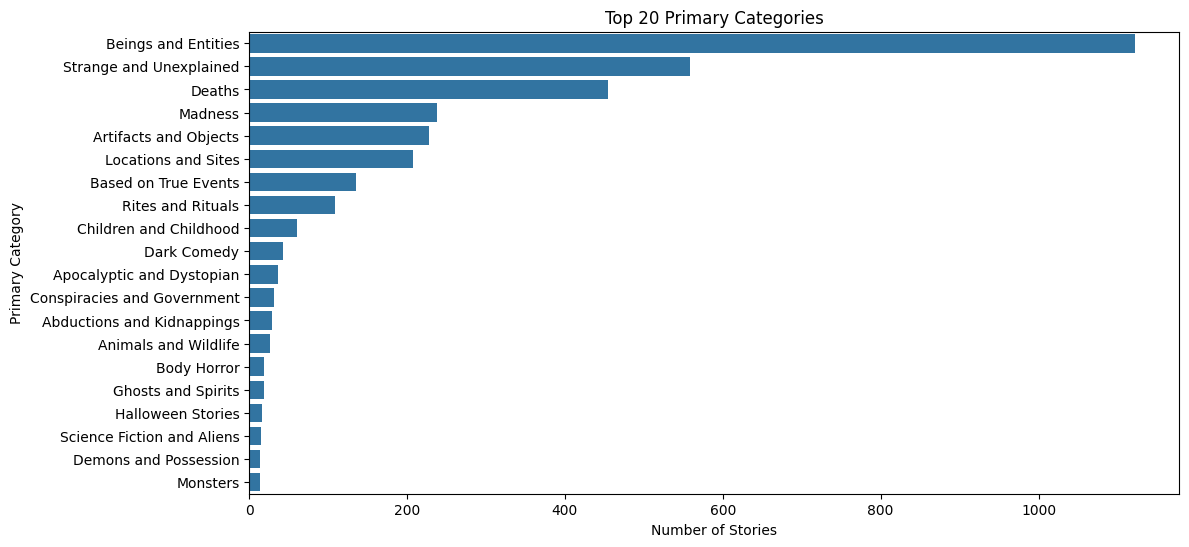

In [29]:
plt.figure(figsize=(12, 6))

sns.barplot(
    x=primary_category_counts.values,
    y=primary_category_counts.index
)

plt.title("Top 20 Primary Categories")
plt.xlabel("Number of Stories")
plt.ylabel("Primary Category")

plt.show()

In [31]:
primary_category_rating_filtered = primary_category_rating[
    primary_category_rating["count"] >= 10
].sort_values("mean", ascending=False)

primary_category_rating_filtered.head(20)

,count,mean
primary_category,,
Based on True Events,135,7.842000
Halloween Stories,16,7.816875
Apocalyptic and Dystopian,36,7.810278
Beings and Entities,1122,7.675178
Children and Childhood,60,7.649500
Deaths,454,7.631806
Monsters,14,7.617143
Conspiracies and Government,31,7.612903
Science Fiction and Aliens,15,7.572667


In [32]:
all_text = " ".join(df["text_lower"].dropna().astype(str))

clean_text = re.sub(r"[^a-zA-Z\s]", " ", all_text)

words = clean_text.split()

print("Total words before filtering:", len(words))

Total words before filtering: 8204973


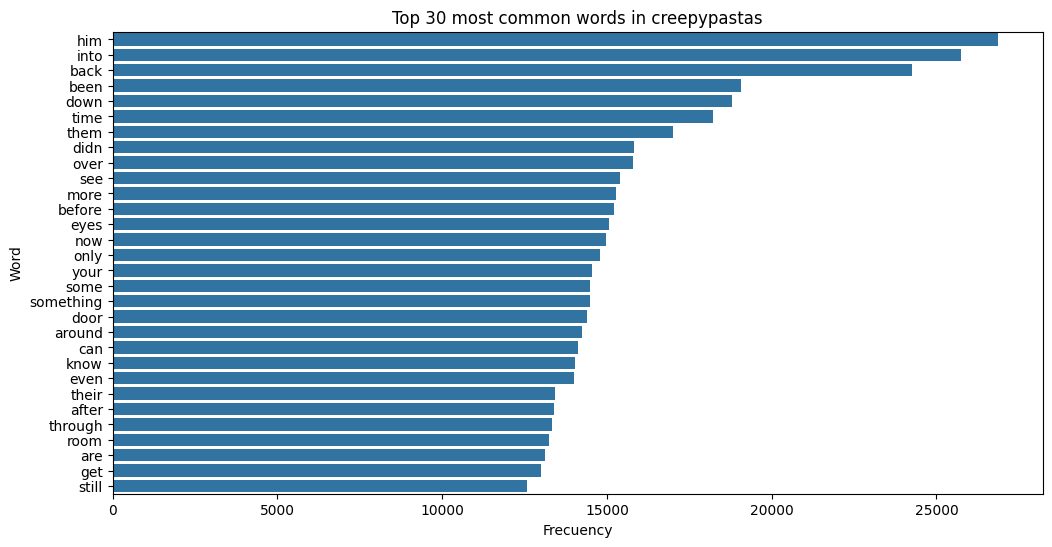

In [22]:
top_words_df = pd.DataFrame(top_words, columns=["word", "count"])

plt.figure(figsize=(12, 6))

sns.barplot(
    data=top_words_df,
    x="count",
    y="word"
)

plt.title("Top 30 most common words in creepypastas")
plt.xlabel("Frecuency")
plt.ylabel("Word")

plt.show()

In [33]:
from sklearn.feature_extraction.text import ENGLISH_STOP_WORDS

custom_stopwords = {
    "said", "like", "just", "one", "would", "could", "get", "got",
    "back", "know", "see", "saw", "didn", "don", "ve", "ll",
    "time", "night", "day", "way", "went", "came", "looked",
    "make", "going", "really", "thing", "things", "people",
    "thought", "think", "little", "old", "new", "right", "left"
}

stopwords = set(ENGLISH_STOP_WORDS).union(custom_stopwords)

filtered_words = [
    word for word in words
    if word.lower() not in stopwords and len(word) > 2
]

print("Total words after filtering:", len(filtered_words))

Total words after filtering: 3083005


In [34]:
word_counts = Counter(filtered_words)

top_words = word_counts.most_common(30)

top_words

[('eyes', 15074),
 ('door', 14410),
 ('room', 13239),
 ('did', 11938),
 ('man', 11562),
 ('face', 10423),
 ('head', 10042),
 ('away', 9868),
 ('house', 9866),
 ('felt', 9207),
 ('wasn', 8582),
 ('long', 8151),
 ('look', 8081),
 ('knew', 7717),
 ('hand', 7566),
 ('couldn', 7512),
 ('heard', 7506),
 ('turned', 7309),
 ('light', 7308),
 ('took', 7150),
 ('began', 7110),
 ('come', 7033),
 ('home', 6895),
 ('started', 6775),
 ('asked', 6646),
 ('body', 6509),
 ('told', 6450),
 ('open', 6086),
 ('let', 6050),
 ('place', 6010)]

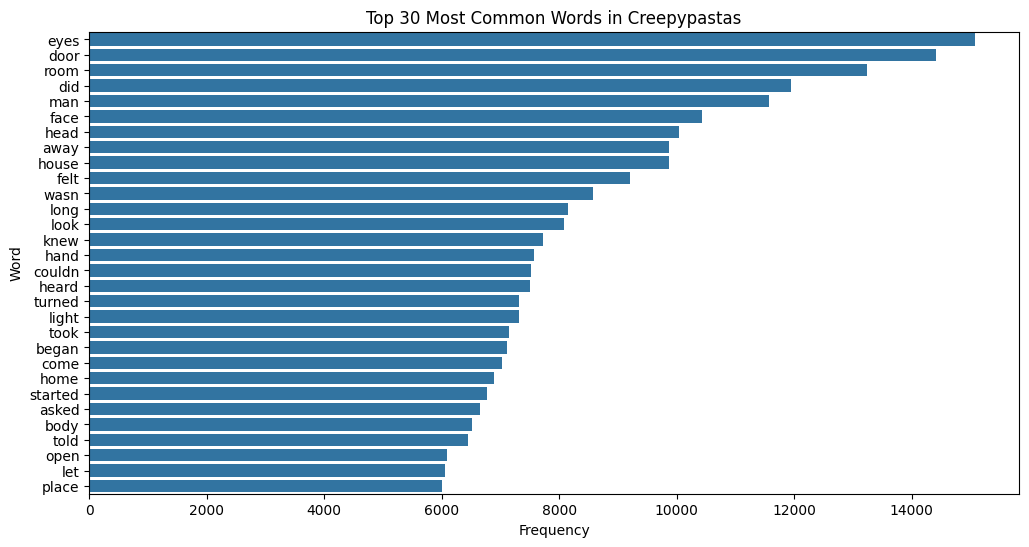

In [35]:
top_words_df = pd.DataFrame(top_words, columns=["word", "count"])

plt.figure(figsize=(12, 6))

sns.barplot(
    data=top_words_df,
    x="count",
    y="word"
)

plt.title("Top 30 Most Common Words in Creepypastas")
plt.xlabel("Frequency")
plt.ylabel("Word")

plt.show()

In [36]:
EDA_DATA_PATH = BASE_DIR / "data" / "processed" / "creepypastas_eda_ready.csv"

df.to_csv(EDA_DATA_PATH, index=False, encoding="utf-8")

print("EDA-ready file saved in:")
print(EDA_DATA_PATH)

EDA-ready file saved in:
../data/processed/creepypastas_eda_ready.csv


In [37]:
# Preliminary EDA Conclusions

# This exploratory analysis shows that the dataset is suitable for NLP-based horror analysis.

# The ratings are concentrated in the upper range, which suggests that the dataset contains many well-received creepypasta stories. Story length has a positive relationship with rating, but it does not fully explain audience reception.

# The analysis of primary categories and frequent words gives a first view of the narrative space of the dataset. However, these surface-level variables are not enough to explain why a horror story feels powerful.

# The next step is to create custom narrative features through the Horror Fracture Index. These features will represent different types of perceptual rupture, such as reality fracture, control loss, body boundary invasion, nonhuman presence, liminal spaces, ritual logic, domestic corruption, and residual impact.